# 01 Bottom-Left 法の復習と動作確認

## 理論まとめ

### BL法とは
空のビンから始めて、矩形を与えられた順序で一つずつ **BL点（最も下で最も左）** に配置する構築型ヒューリスティック。

### BL実行可能点（BL feasible point）
矩形 $r$ を置いたとき、以下を同時に満たす座標 $p$:
- 既配置の矩形と重ならない
- ビンからはみ出さない
- $p$ から **下にも左にも動かせない**（これ以上BL方向に移動できない）

### BL点
BL実行可能点の中で **y が最小、同じなら x が最小** の点。

### 候補点の列挙（なぜコーナーだけでよいか）
BL実行可能点は必ず以下のいずれかで一意に決まる:

| 種別 | 下方向に接するもの | 左方向に接するもの |
|------|-------------------|-------------------|
| A | 容器の底辺 | 容器の左辺 |
| B | 矩形 k の上辺 | 矩形 j の右辺 |
| C | 矩形 j の上辺 | 容器の左辺 |
| D | 容器の底辺 | 矩形 j の右辺 |

→ 候補点は $O(n^2)$ 個、各候補への重なり判定は $O(n)$ → BL点探索は $O(n^3)$ → 全体 $O(n^4)$

In [2]:
import sys
sys.path.insert(0, '..')

from algorithms.bottom_left import bl_method, bl_candidates, is_feasible
from utils.visualizer import plot_packing, plot_comparison
import time

## 1. 論文の例題で動作確認

今堀ら (2018) の OR 学会誌記事の例題 `w=[9,4,4,7,5], h=[4,10,9,9,10], W=20` を使う。

In [3]:
# 論文の例題
rects = [(9,4), (4,10), (4,9), (7,9), (5,10)]
bin_w = 20

positions, sorted_rects = bl_method(rects, bin_w, sort_key='area')

print('配置結果（入力順）:')
for i, ((w, h), (x, y)) in enumerate(zip(rects, positions)):
    print(f'  矩形{i} ({w}×{h})  →  ({x:.1f}, {y:.1f})')

bin_h = max(y + h for (_, h), (_, y) in zip(rects, positions))
total_area = sum(w * h for w, h in rects)
fill_rate = total_area / (bin_w * bin_h) * 100
print(f'\n使用した高さ: {bin_h:.1f}')
print(f'充填率: {fill_rate:.1f}%')

配置結果（入力順）:
  矩形0 (9×4)  →  (0.0, 10.0)
  矩形1 (4×10)  →  (12.0, 0.0)
  矩形2 (4×9)  →  (16.0, 0.0)
  矩形3 (7×9)  →  (0.0, 0.0)
  矩形4 (5×10)  →  (7.0, 0.0)

使用した高さ: 14.0
充填率: 80.4%


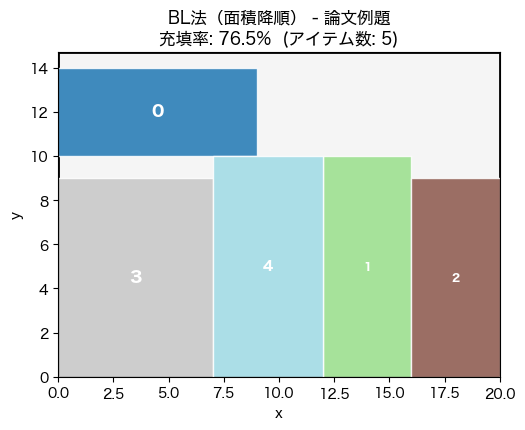

<Axes: title={'center': 'BL法（面積降順） - 論文例題\n充填率: 76.5%  (アイテム数: 5)'}, xlabel='x', ylabel='y'>

In [4]:
# 可視化
plot_packing(rects, positions, bin_w, title='BL法（面積降順） - 論文例題')

## 2. ソート順による結果の違いを比較

In [7]:
import numpy as np

# ランダムな矩形を生成（再現性のためシードを固定）
rng = np.random.default_rng(seed=42)
n = 15
bin_w = 30
rects_rand = [
    (float(rng.integers(2, 10)), float(rng.integers(2, 10)))
    for _ in range(n)
]

results = []
for key in ['none', 'area', 'width', 'height']:
    t0 = time.perf_counter()
    pos, _ = bl_method(rects_rand, bin_w, sort_key=key)
    elapsed = time.perf_counter() - t0

    used_h = max(y + h for (_, h), (_, y) in zip(rects_rand, pos))
    total_area = sum(w * h for w, h in rects_rand)
    fill = total_area / (bin_w * used_h) * 100

    print(f'sort={key:8s}  高さ={used_h:5.1f}  充填率={fill:5.1f}%  時間={elapsed:.4f}s')
    results.append({'label': f'sort={key}', 'rects': rects_rand, 'positions': pos, 'time': elapsed})

sort=none      高さ= 22.0  充填率= 77.6%  時間=0.0087s
sort=area      高さ= 20.0  充填率= 85.3%  時間=0.0083s
sort=width     高さ= 21.0  充填率= 81.3%  時間=0.0106s
sort=height    高さ= 19.0  充填率= 89.8%  時間=0.0099s


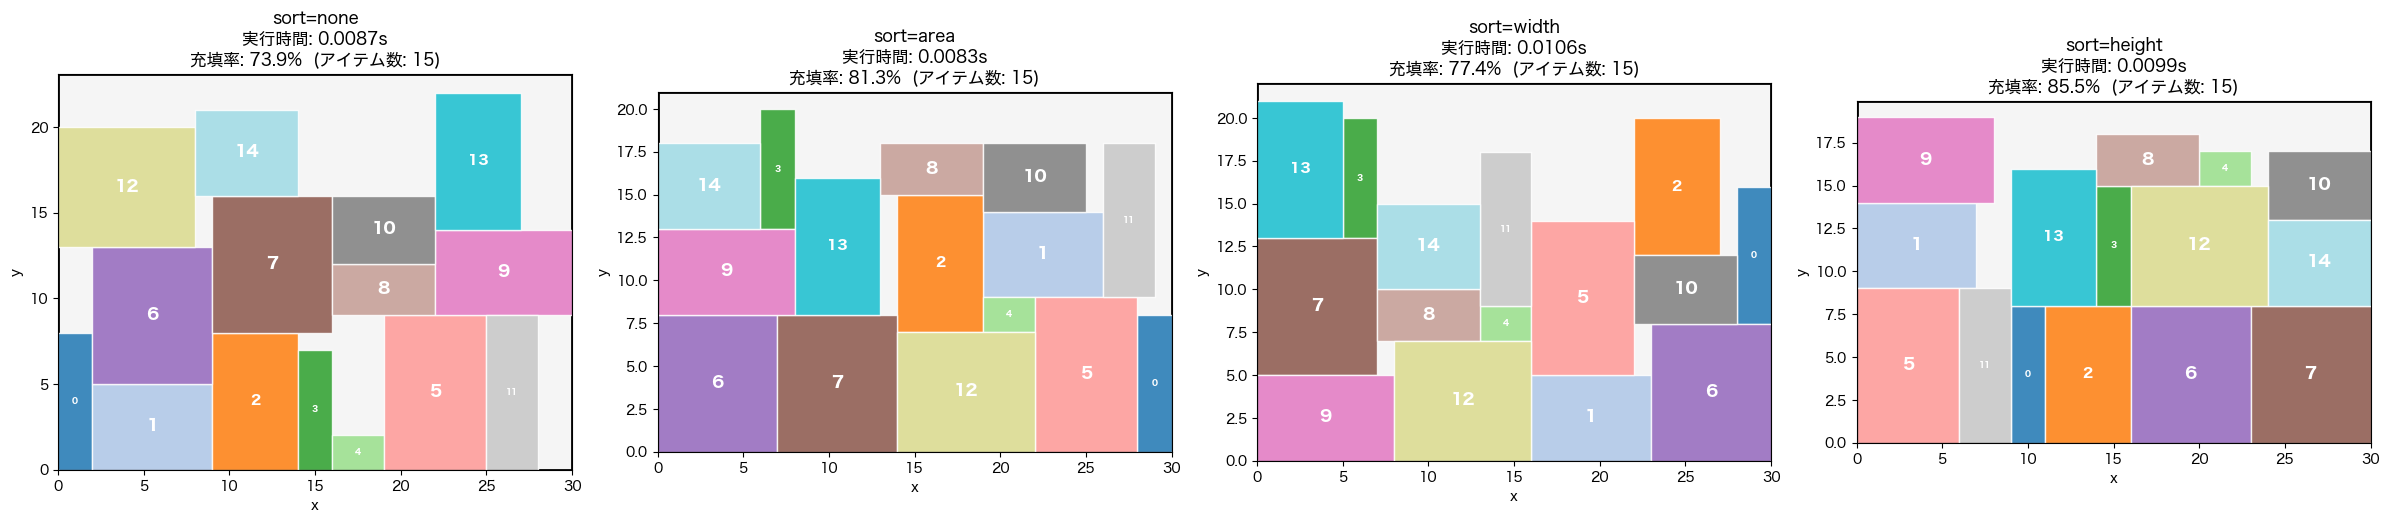

In [8]:
# 4パターンを横並び比較
plot_comparison(results, bin_w)

## 3. 計算時間の計測（n に対するスケーリング）

O(n^4) の理論に合っているか確認する。

n=  5  時間=0.0002s
n= 10  時間=0.0020s
n= 20  時間=0.0423s
n= 30  時間=0.2839s
n= 40  時間=0.4565s
n= 50  時間=0.8689s


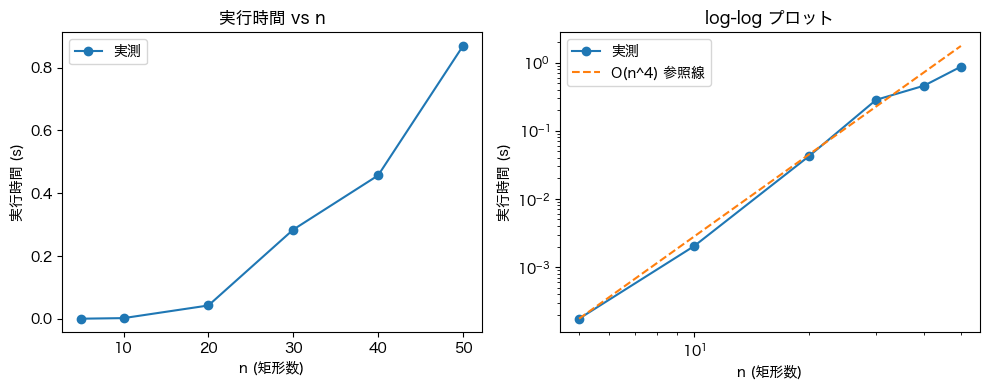

In [9]:
import matplotlib.pyplot as plt

ns = [5, 10, 20, 30, 40, 50]
times = []

for n in ns:
    rng = np.random.default_rng(seed=0)
    rects_n = [(float(rng.integers(2, 8)), float(rng.integers(2, 8))) for _ in range(n)]
    bin_w_n = 30

    t0 = time.perf_counter()
    bl_method(rects_n, bin_w_n, sort_key='area')
    elapsed = time.perf_counter() - t0
    times.append(elapsed)
    print(f'n={n:3d}  時間={elapsed:.4f}s')

# プロット
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(ns, times, 'o-', label='実測')
axes[0].set_xlabel('n (矩形数)')
axes[0].set_ylabel('実行時間 (s)')
axes[0].set_title('実行時間 vs n')
axes[0].legend()

# log-log でプロット → 傾きが計算量の次数に対応
axes[1].loglog(ns, times, 'o-', label='実測')
# O(n^4) の参照線
ref = [times[0] * (ni / ns[0]) ** 4 for ni in ns]
axes[1].loglog(ns, ref, '--', label='O(n^4) 参照線')
axes[1].set_xlabel('n (矩形数)')
axes[1].set_ylabel('実行時間 (s)')
axes[1].set_title('log-log プロット')
axes[1].legend()

plt.tight_layout()
plt.show()

## まとめ・次のステップ

- BL法（単純実装）が正しく動作することを確認した
- ソート順（面積降順）が充填率を改善することを確認した
- 計算時間は O(n^4) のスケーリングに沿っている

**次: `02_nfp_bottom_left.ipynb`**
- No-Fit Polygon (NFP) を実装して BL点探索を O(n^2 log n) に高速化
- 単純実装との速度比較ベンチマーク